# EM1 Fault / Alarm Classification Example

This notebook-style Python script shows a simple classification workflow for
`EM1` using the workbook data already included in this project.

Goal:
- predict whether the next EM1 machine state will be `alarm`

Data used:
- `RawData`
- `SensorData`

Model used:
- `RandomForestClassifier`



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


CURRENT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
WORKBOOK_PATH = PROJECT_ROOT / "AIM_MonitoringSystem.xlsx"
TARGET_MACHINE = "EM1"

print(f"Project root: {PROJECT_ROOT}")
print(f"Workbook path: {WORKBOOK_PATH}")




Project root: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM
Workbook path: c:\Users\fairu\OneDrive - unimap.edu.my\Unimap\HP documents\Research\MOSTI\pprn\AIM\AIM_MonitoringSystem.xlsx


## 1. Load workbook data



In [2]:
raw_df = pd.read_excel(WORKBOOK_PATH, sheet_name="RawData")
sensor_df = pd.read_excel(WORKBOOK_PATH, sheet_name="SensorData")

raw_df["Timestamp"] = pd.to_datetime(raw_df["Timestamp"], errors="coerce")
sensor_df["Timestamp"] = pd.to_datetime(sensor_df["Timestamp"], errors="coerce")

raw_df = raw_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
sensor_df = sensor_df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

print("RawData rows:", len(raw_df))
print("SensorData rows:", len(sensor_df))
raw_df.head()




RawData rows: 15645
SensorData rows: 63262


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.000000,NaN
1,2026-05-07 14:15:31.257,EM2,running,4.65,NaN,NaN,1.941721,NaN
2,2026-05-07 14:15:31.257,EM3,running,3.97,NaN,NaN,0.000000,NaN
3,2026-05-07 14:15:31.257,EM4,alarm,5.20,AL030,Final inspection reject rate high,9.000000,NaN
4,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.000000,NaN


## 2. Filter EM1 data only



In [3]:
raw_em1 = raw_df.loc[raw_df["Machine"] == TARGET_MACHINE].copy()
sensor_em1 = sensor_df.loc[sensor_df["Machine"] == TARGET_MACHINE].copy()

print("EM1 raw rows:", len(raw_em1))
print("EM1 sensor rows:", len(sensor_em1))
raw_em1.head()




EM1 raw rows: 3930
EM1 sensor rows: 18510


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN
4,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN
8,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN
11,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN
17,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN


## 3. Build sensor snapshot features



In [4]:
sensor_snapshot = (
    sensor_em1.pivot_table(
        index="Timestamp",
        columns="SensorID",
        values="Value",
        aggfunc="last",
    )
    .sort_index()
    .reset_index()
)

sensor_snapshot.columns.name = None
sensor_snapshot.head()




,Timestamp,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:20:31.257,6.74,0.22,4.21,207.05,210.36
1,2026-05-07 14:25:31.257,6.11,0.15,3.83,208.43,207.25
2,2026-05-07 14:30:31.257,6.56,0.28,2.10,214.02,202.39
3,2026-05-07 14:35:31.257,6.82,0.33,4.78,219.03,206.50
4,2026-05-07 14:38:35.022,6.30,0.24,4.27,214.73,201.37


## 4. Merge machine-level data with nearest sensor snapshot



In [5]:
raw_em1 = raw_em1.sort_values("Timestamp").reset_index(drop=True)
sensor_snapshot = sensor_snapshot.sort_values("Timestamp").reset_index(drop=True)

model_df = pd.merge_asof(
    raw_em1,
    sensor_snapshot,
    on="Timestamp",
    direction="backward",
)

print("Merged rows:", len(model_df))
model_df.head()




Merged rows: 3930


,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes,EM1_CURR_01,EM1_POSN_01,EM1_PRES_01,EM1_TEMP_01,EM1_TEMP_02
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN,6.74,0.22,4.21,207.05,210.36
2,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN,6.11,0.15,3.83,208.43,207.25
3,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN,6.56,0.28,2.10,214.02,202.39
4,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN,6.82,0.33,4.78,219.03,206.50


## 5. Create classification target and simple features



In [6]:
model_df["CycleTime_lag1"] = model_df["CycleTime_sec"].shift(1)
model_df["CycleTime_lag2"] = model_df["CycleTime_sec"].shift(2)
model_df["CycleTime_roll3"] = model_df["CycleTime_sec"].rolling(window=3).mean()
model_df["RejectCount_lag1"] = model_df["RejectCount"].shift(1)
model_df["RejectCount_roll3"] = model_df["RejectCount"].rolling(window=3).mean()
model_df["Hour"] = model_df["Timestamp"].dt.hour
model_df["MinuteOfDay"] = model_df["Timestamp"].dt.hour * 60 + model_df["Timestamp"].dt.minute
model_df["IsAlarmNow"] = (model_df["Status"] == "alarm").astype(int)
model_df["IsRunningNow"] = (model_df["Status"] == "running").astype(int)

# Predict whether the next row becomes an alarm state.
model_df["NextStatus"] = model_df["Status"].shift(-1)
model_df["Target_NextAlarm"] = (model_df["NextStatus"] == "alarm").astype(int)

model_df = model_df.dropna(subset=["NextStatus"]).reset_index(drop=True)
model_df.head()




,Timestamp,Machine,Status,CycleTime_sec,AlarmCode,AlarmMessage,RejectCount,Notes,EM1_CURR_01,EM1_POSN_01,...,CycleTime_lag2,CycleTime_roll3,RejectCount_lag1,RejectCount_roll3,Hour,MinuteOfDay,IsAlarmNow,IsRunningNow,NextStatus,Target_NextAlarm
0,2026-05-07 14:15:31.257,EM1,idle,4.08,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,14,855,0,0,running,0
1,2026-05-07 14:20:31.257,EM1,running,3.82,NaN,NaN,0.0,NaN,6.74,0.22,...,NaN,NaN,0.0,NaN,14,860,0,1,running,0
2,2026-05-07 14:25:31.257,EM1,running,4.47,NaN,NaN,0.0,NaN,6.11,0.15,...,4.08,4.123333,0.0,0.0,14,865,0,1,alarm,1
3,2026-05-07 14:30:31.257,EM1,alarm,5.80,AL002,Clamp pressure low,0.0,NaN,6.56,0.28,...,3.82,4.696667,0.0,0.0,14,870,1,0,running,0
4,2026-05-07 14:35:31.257,EM1,running,4.01,NaN,NaN,0.0,NaN,6.82,0.33,...,4.47,4.760000,0.0,0.0,14,875,0,1,running,0


## 6. Choose features



In [7]:
sensor_feature_cols = [col for col in sensor_snapshot.columns if col != "Timestamp"]
base_feature_cols = [
    "CycleTime_sec",
    "CycleTime_lag1",
    "CycleTime_lag2",
    "CycleTime_roll3",
    "RejectCount",
    "RejectCount_lag1",
    "RejectCount_roll3",
    "Hour",
    "MinuteOfDay",
    "IsAlarmNow",
    "IsRunningNow",
]

feature_cols = [col for col in base_feature_cols + sensor_feature_cols if col in model_df.columns]
target_col = "Target_NextAlarm"

dataset = model_df[["Timestamp"] + feature_cols + [target_col]].dropna().copy()

print("Feature count:", len(feature_cols))
print("Dataset rows:", len(dataset))
print("Alarm rate:", dataset[target_col].mean())
feature_cols




Feature count: 16
Dataset rows: 3927
Alarm rate: 0.11841100076394194


['CycleTime_sec',
 'CycleTime_lag1',
 'CycleTime_lag2',
 'CycleTime_roll3',
 'RejectCount',
 'RejectCount_lag1',
 'RejectCount_roll3',
 'Hour',
 'MinuteOfDay',
 'IsAlarmNow',
 'IsRunningNow',
 'EM1_CURR_01',
 'EM1_POSN_01',
 'EM1_PRES_01',
 'EM1_TEMP_01',
 'EM1_TEMP_02']

## 7. Train/test split by time



In [8]:
split_index = int(len(dataset) * 0.8)
train_df = dataset.iloc[:split_index].copy()
test_df = dataset.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train alarm rate:", y_train.mean())
print("Test alarm rate:", y_test.mean())




Train rows: 3141
Test rows: 786
Train alarm rate: 0.11970709964979306
Test alarm rate: 0.11323155216284987


## 8. Train a simple classification pipeline



In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            feature_cols,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=8,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
pred_test = model.predict(X_test)
pred_proba_test = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_test, digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, pred_proba_test):.4f}")




              precision    recall  f1-score   support

           0     0.8866    0.9756    0.9290       697
           1     0.1053    0.0225    0.0370        89

    accuracy                         0.8677       786
   macro avg     0.4959    0.4990    0.4830       786
weighted avg     0.7981    0.8677    0.8280       786

ROC-AUC: 0.5184


## 9. Confusion matrix



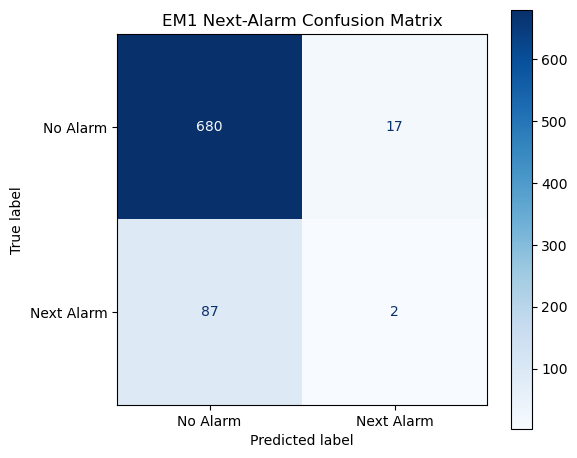

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test,
    display_labels=["No Alarm", "Next Alarm"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("EM1 Next-Alarm Confusion Matrix")
plt.tight_layout()
plt.show()




## 10. Predicted alarm probability over time



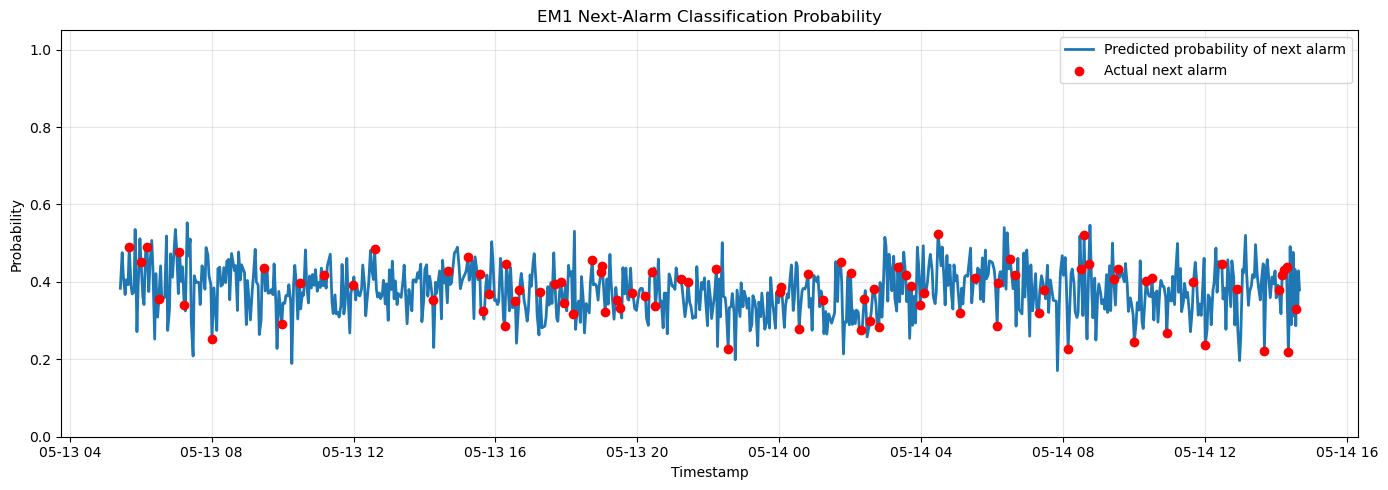

In [11]:
results_df = pd.DataFrame(
    {
        "Timestamp": test_df["Timestamp"],
        "ActualNextAlarm": y_test.values,
        "PredictedAlarmProbability": pred_proba_test,
        "PredictedNextAlarm": pred_test,
    }
)

plt.figure(figsize=(14, 5))
plt.plot(
    results_df["Timestamp"],
    results_df["PredictedAlarmProbability"],
    label="Predicted probability of next alarm",
    linewidth=2,
)
plt.scatter(
    results_df.loc[results_df["ActualNextAlarm"] == 1, "Timestamp"],
    results_df.loc[results_df["ActualNextAlarm"] == 1, "PredictedAlarmProbability"],
    color="red",
    label="Actual next alarm",
    zorder=3,
)
plt.title("EM1 Next-Alarm Classification Probability")
plt.xlabel("Timestamp")
plt.ylabel("Probability")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




## 11. Feature importance



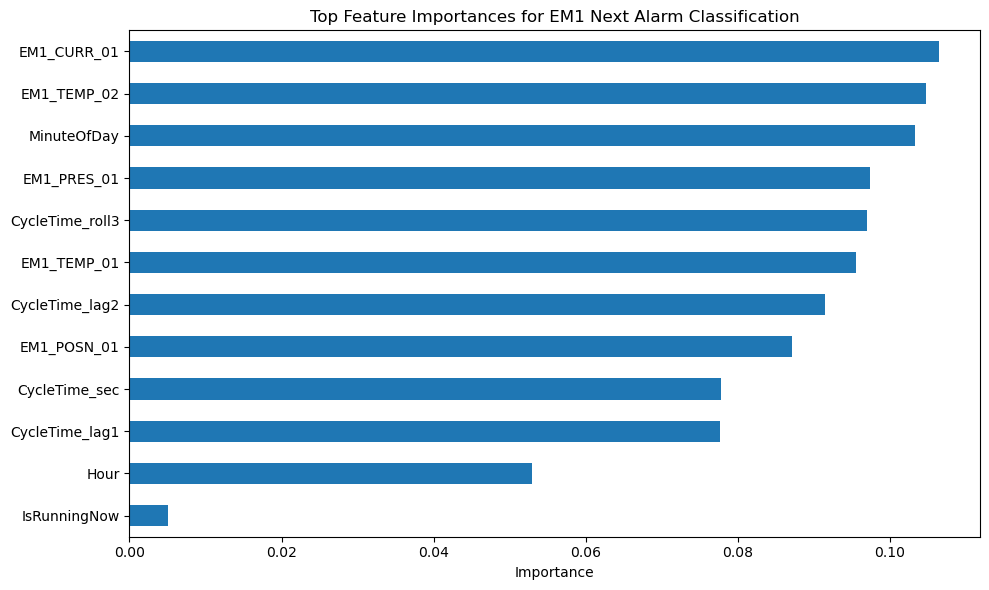

EM1_CURR_01        0.106499
EM1_TEMP_02        0.104789
MinuteOfDay        0.103240
EM1_PRES_01        0.097376
CycleTime_roll3    0.097029
EM1_TEMP_01        0.095520
CycleTime_lag2     0.091447
EM1_POSN_01        0.087084
CycleTime_sec      0.077810
CycleTime_lag1     0.077621
Hour               0.052972
IsRunningNow       0.005121
dtype: float64

In [12]:
rf_model = model.named_steps["classifier"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_n = 12
plt.figure(figsize=(10, 6))
importances.head(top_n).sort_values().plot(kind="barh")
plt.title("Top Feature Importances for EM1 Next Alarm Classification")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(top_n)




## 12. Latest-row example prediction



In [13]:
latest_row = dataset.iloc[[-1]][feature_cols]
next_alarm_probability = model.predict_proba(latest_row)[0, 1]
next_alarm_prediction = model.predict(latest_row)[0]

print("Latest EM1 feature row timestamp:", dataset.iloc[-1]["Timestamp"])
print(f"Predicted probability of next alarm: {next_alarm_probability:.4f}")
print("Predicted next state alarm flag:", int(next_alarm_prediction))




Latest EM1 feature row timestamp: 2026-05-14 14:39:55.770000
Predicted probability of next alarm: 0.3796
Predicted next state alarm flag: 0


## Notes

This is intentionally a simple example for GitHub and experimentation.
Good next steps would be:
- classify specific EM1 alarm codes instead of only alarm/non-alarm
- predict alarms several steps ahead
- add anomaly-derived features from `AnomalyLog`
- compare classifier performance against gradient boosting models
